## Overview

This notebook demonstrates the end-to-end process of:

loading Ghana petroleum tracking data from Excel
cleaning and transforming the dataset
calculating analytics metrics
exporting a clean analytics-ready dataset
preparing data for EDA, SQL analytics, and dashboarding

## Analytics Engineering Layer

In addition to exploratory analysis in Python, this project includes a DuckDB database layer for SQL-based analytics.

The cleaned petroleum dataset is loaded into DuckDB as a table called:petroleum_analytics

## Data Preparation

Raw petroleum production and revenue data was consolidated from PIAC annual reports into a structured tracking worksheet. Python transformation scripts were then used to clean, standardize, and enrich the dataset prior to analysis.

Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Load Data

In [14]:


PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "ghana_petroleum_analytics.csv")

df.head()

,year,total_production_barrels,petroleum_revenue_usd,brent_price_usd,source,revenue_per_barrel
0,2011,24000000.0,444120000.0,111.26,PIAC 2011 Annual Report,18.505000
1,2012,26351278.0,541620000.0,111.63,PIAC 2012 Annual Report,20.553842
2,2013,35587558.0,846770000.0,108.56,PIAC 2013 Annual Report,23.793990
3,2014,37201691.0,978020000.0,98.97,PIAC 2014 Annual Report,26.289665
4,2015,37411661.0,396170000.0,52.32,PIAC 2015 Annual Report,10.589479


Data Inspection

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      15 non-null     int64  
 1   total_production_barrels  15 non-null     float64
 2   petroleum_revenue_usd     15 non-null     float64
 3   brent_price_usd           15 non-null     float64
 4   source                    15 non-null     object 
 5   revenue_per_barrel        15 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 852.0+ bytes


In [16]:
df.isnull().sum()

year                        0
total_production_barrels    0
petroleum_revenue_usd       0
brent_price_usd             0
source                      0
revenue_per_barrel          0
dtype: int64

Revenue Analysis

In [23]:
df[
    [
        "year",
        "petroleum_revenue_usd",
        "total_production_barrels",
        "revenue_per_barrel"
    ]
]

,year,petroleum_revenue_usd,total_production_barrels,revenue_per_barrel
0,2011,4.441200e+08,24000000.00,18.505000
1,2012,5.416200e+08,26351278.00,20.553842
2,2013,8.467700e+08,35587558.00,23.793990
3,2014,9.780200e+08,37201691.00,26.289665
4,2015,3.961700e+08,37411661.00,10.589479
5,2016,2.471800e+08,32298638.00,7.652954
6,2017,5.553300e+08,58658063.54,9.467241
7,2018,9.770900e+08,62135435.07,15.725166
8,2019,9.250400e+08,71439585.00,12.948563
9,2020,6.663908e+08,66926806.00,9.957008


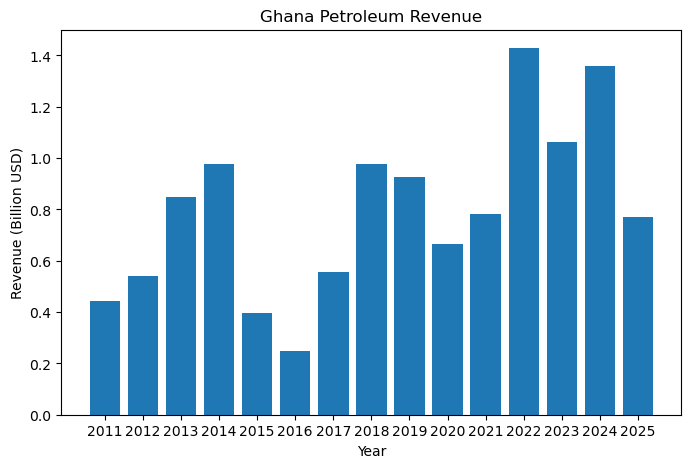

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    df["year"].astype(str),
    df["petroleum_revenue_usd"] / 1e9
)

plt.title("Ghana Petroleum Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue (Billion USD)")

plt.show()

## Ghana Petroleum Revenue Trends — Key Insights

- Ghana’s petroleum revenue increased steadily between 2011 and 2014, reflecting the early expansion of the country’s oil sector and relatively strong global oil prices during that period.

- Petroleum revenue declined sharply between 2014 and 2016, reaching its lowest point in 2016 at approximately USD 247 million.

- The decline in revenue during 2015–2016 coincided with the global oil price crash, indicating that Ghana’s petroleum earnings were highly sensitive to international crude oil market conditions.

- Petroleum revenue began recovering after 2016 as global oil prices stabilized and production levels improved.

- 2018 and 2019 recorded strong revenue performance, with annual petroleum receipts approaching USD 1 billion.

- Petroleum revenue declined again in 2020, likely reflecting disruptions in global energy markets and weaker oil prices during the COVID-19 pandemic period.

- Revenue recovered between 2021 and 2022, with 2022 recording the highest petroleum revenue in the dataset at approximately USD 1.43 billion.

- Elevated revenues in 2022 were likely influenced by exceptionally high global oil prices during the global energy market disruption period.

- Petroleum revenue declined in 2023 before recovering again in 2024, despite lower Brent crude prices compared to 2022.

- The decline in 2025 suggests a potential weakening in petroleum receipts, lower oil prices, reduced production, or incomplete year-end reporting.

- Overall, the analysis suggests that Ghana’s petroleum revenues were strongly influenced by global oil market cycles, while production levels and revenue efficiency also contributed to revenue performance.

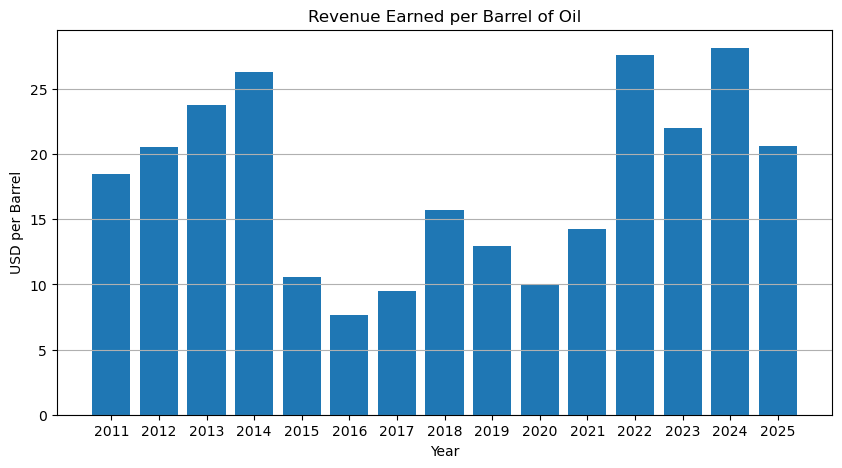

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["year"].astype(str),
    df["revenue_per_barrel"]
)

plt.title("Revenue Earned per Barrel of Oil")
plt.xlabel("Year")
plt.ylabel("USD per Barrel")

plt.grid(axis="y")

plt.show()

## Revenue Earned per Barrel — Key Insights

- Revenue earned per barrel increased steadily between 2011 and 2014, indicating improving petroleum revenue efficiency during the early growth phase of Ghana’s oil sector.

- Revenue efficiency declined sharply between 2015 and 2017, reaching its lowest point in 2016 at approximately USD 7–8 per barrel.

- The decline in revenue efficiency during 2015–2017 coincided with a major global oil price downturn, suggesting that weaker international crude prices significantly reduced Ghana’s petroleum earnings per barrel.

- Revenue efficiency began recovering after 2017 as global oil market conditions improved.

- 2022 and 2024 recorded the highest revenue-per-barrel values in the dataset, exceeding USD 27 per barrel.

- Strong revenue efficiency in 2022 aligned with elevated global Brent crude prices during the global energy market disruption period.

- Revenue efficiency remained relatively high in 2024 despite lower Brent prices compared to 2022, suggesting that factors beyond oil prices — such as fiscal policy, production agreements, or revenue management — may also influence petroleum earnings.

- Revenue efficiency declined again in 2025, potentially reflecting weaker global oil prices or reduced petroleum receipts.

- Overall, the analysis suggests that Ghana’s petroleum revenue performance was more strongly influenced by oil market conditions and revenue efficiency than by production volumes alone.


In [27]:
df["revenue_per_barrel"].describe()

count    15.000000
mean     17.875563
std       6.926203
min       7.652954
25%      11.769021
50%      18.505000
75%      22.906204
max      28.146633
Name: revenue_per_barrel, dtype: float64

Production Analysis

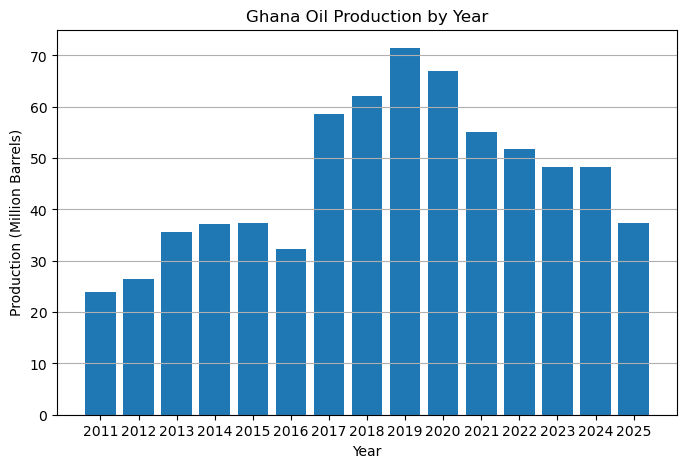

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df["year"].astype(str),
    df["total_production_barrels"] / 1e6
)

plt.title("Ghana Oil Production by Year")
plt.xlabel("Year")
plt.ylabel("Production (Million Barrels)")

plt.grid(axis="y")

plt.show()

## Ghana Oil Production Trends — Key Insights

- Ghana’s oil production increased steadily between 2011 and 2015, reflecting the expansion of the country’s petroleum sector following the start of commercial oil production.

- Production declined in 2016 before recovering strongly between 2017 and 2019.

- 2019 recorded the highest production level in the dataset at approximately 71 million barrels, representing the peak production year during the observed period.

- Oil production remained relatively strong between 2018 and 2020 before entering a gradual decline after 2020.

- Production decreased consistently from 2020 through 2025, indicating possible production slowdowns, maturing oil fields, or operational constraints.

- Despite declining production after 2020, petroleum revenues remained relatively strong in some years, suggesting that global oil prices and revenue efficiency also played important roles in determining petroleum earnings.

- The long-term trend suggests that Ghana’s petroleum sector experienced rapid growth during its early years, followed by stabilization and gradual decline in later years.


Brent Price Analysis

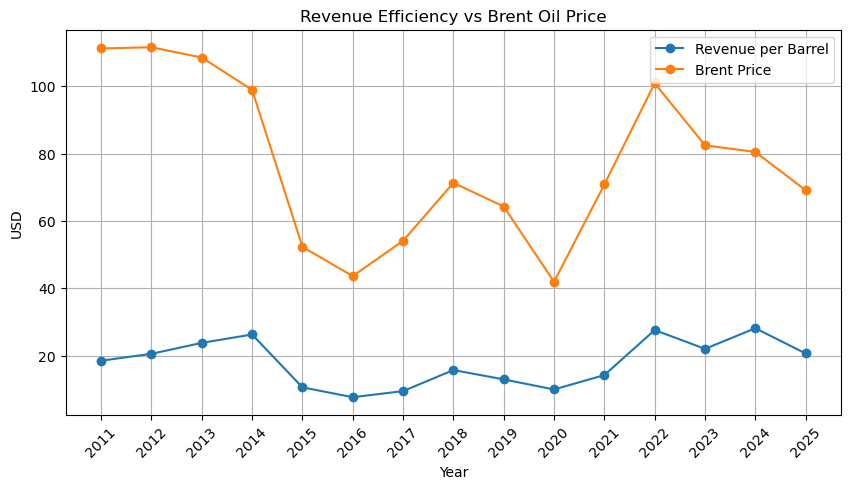

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["year"],
    df["revenue_per_barrel"],
    marker="o",
    label="Revenue per Barrel"
)

plt.plot(
    df["year"],
    df["brent_price_usd"],
    marker="o",
    label="Brent Price"
)

plt.xticks(df["year"], rotation=45)

plt.title("Revenue Efficiency vs Brent Oil Price")
plt.xlabel("Year")
plt.ylabel("USD")

plt.legend()

plt.grid(True)

plt.show()

## Revenue Efficiency vs Brent Oil Price — Key Insights

- Revenue per barrel generally moved in the same direction as Brent crude oil prices, suggesting that global oil market conditions significantly influenced Ghana’s petroleum earnings.

- The sharp decline in Brent prices between 2014 and 2016 coincided with a major drop in Ghana’s revenue per barrel, reflecting the global oil price downturn during that period.

- Revenue efficiency recovered after 2016 as Brent prices stabilized and global oil market conditions improved.

- 2022 recorded the highest Brent crude prices in the dataset and corresponded with one of the strongest petroleum revenue environments for Ghana.

- Revenue per barrel remained relatively strong in 2024 despite lower Brent prices compared to 2022, suggesting that factors beyond global oil prices may also influence petroleum revenues.

- The relationship between Brent prices and revenue efficiency is strong but not perfect, indicating that production levels, fiscal policy, exchange rates, and petroleum agreements may also affect Ghana’s petroleum earnings.

- Production levels were relatively more stable over time than revenue efficiency, implying that oil price fluctuations had a larger impact on petroleum revenue than production volumes alone.


Correlation Analysis

In [22]:
correlation = df.corr(numeric_only=True)

correlation

,year,total_production_barrels,petroleum_revenue_usd,brent_price_usd,revenue_per_barrel
year,1.000000,0.522672,0.587815,-0.356784,0.175191
total_production_barrels,0.522672,1.000000,0.397334,-0.512156,-0.281049
petroleum_revenue_usd,0.587815,0.397334,1.000000,0.341388,0.747534
brent_price_usd,-0.356784,-0.512156,0.341388,1.000000,0.784213
revenue_per_barrel,0.175191,-0.281049,0.747534,0.784213,1.000000


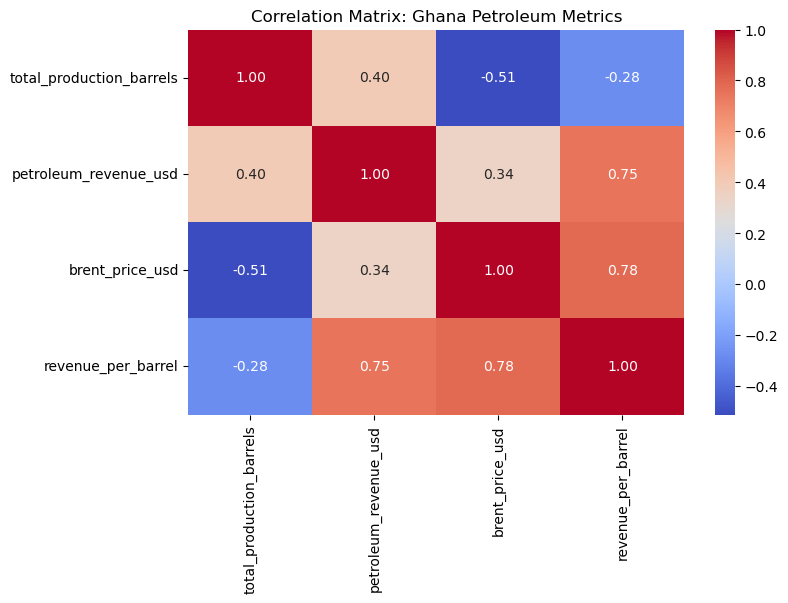

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "total_production_barrels",
    "petroleum_revenue_usd",
    "brent_price_usd",
    "revenue_per_barrel"
]

correlation = df[corr_cols].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix: Ghana Petroleum Metrics")

plt.show()

## Correlation Matrix Insights

- Brent crude oil prices and revenue per barrel showed a strong positive correlation (0.78), indicating that higher global oil prices were generally associated with higher petroleum revenue efficiency in Ghana.

- Petroleum revenue and revenue per barrel also had a strong positive relationship (0.75), suggesting that Ghana’s petroleum earnings were heavily influenced by how much revenue was generated per barrel produced.

- Total production barrels had only a moderate positive correlation with petroleum revenue (0.40), implying that production volume alone did not fully determine petroleum earnings.

- Brent crude prices and petroleum revenue showed a moderate positive correlation (0.34), indicating that global oil prices influenced Ghana’s petroleum revenue but were not the sole driver.

- Total production barrels and Brent crude prices had a moderate negative correlation (-0.51), suggesting that higher production levels did not always coincide with periods of high global oil prices.

- Total production barrels and revenue per barrel also showed a weak negative relationship (-0.28), indicating that increased production did not necessarily translate into higher revenue efficiency.

- Overall, the analysis suggests that Ghana’s petroleum revenue performance was influenced more strongly by oil market prices and revenue efficiency than by production volumes alone.

# 10. Key Findings

- Ghana’s petroleum sector experienced significant growth during the early years of commercial oil production, with production and revenues increasing steadily between 2011 and 2014.

- Petroleum revenues declined sharply during the 2015–2016 global oil price downturn, demonstrating the sector’s sensitivity to international crude oil market conditions.

- Oil production peaked in 2019 at approximately 71 million barrels before entering a gradual decline in subsequent years.

- Brent crude oil prices showed a strong positive relationship with Ghana’s revenue per barrel, indicating that global oil market prices strongly influenced petroleum revenue efficiency.

- Petroleum revenues recovered significantly in 2022, which recorded the highest petroleum revenue in the dataset at approximately USD 1.43 billion.

- Revenue efficiency remained relatively strong in 2024 despite lower Brent prices compared to 2022, suggesting that factors beyond oil prices may also influence petroleum earnings.

- Correlation analysis suggests that petroleum revenue performance was more strongly influenced by oil prices and revenue efficiency than by production volumes alone.

- Overall, Ghana’s petroleum sector performance reflects a combination of production trends, global oil market cycles, and revenue efficiency dynamics.

# 11. Limitations

- The analysis uses annual aggregated data, which may hide short-term market and operational fluctuations.

- Correlation analysis does not imply causation and should be interpreted cautiously.

- Some production values were manually extracted from public reports, which may introduce minor inconsistencies.

- The analysis does not include additional macroeconomic variables such as exchange rates, inflation, taxation, or government expenditure.

- Field-level production data was not incorporated into the current analysis.

- The 2025 data may represent partial-year reporting and may not reflect full-year petroleum receipts or production levels.

# 12. Future Improvements

- Add monthly and quarterly petroleum production and revenue data for deeper time series analysis.

- Incorporate field-level production data for Jubilee, TEN, and SGN fields.

- Add exchange rate and inflation datasets to improve macroeconomic analysis.

- Automate data extraction from PIAC PDF reports using Python PDF extraction libraries.

- Add forecasting models to predict petroleum revenues and production trends.

- Containerize the project using Docker for improved reproducibility and deployment.

- Expand the project into a full end-to-end data engineering pipeline with orchestration tools such as Apache Airflow.